In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

from utilities import *

Dimension de X:  (2, 100)
Dimension de y:  (1, 100)


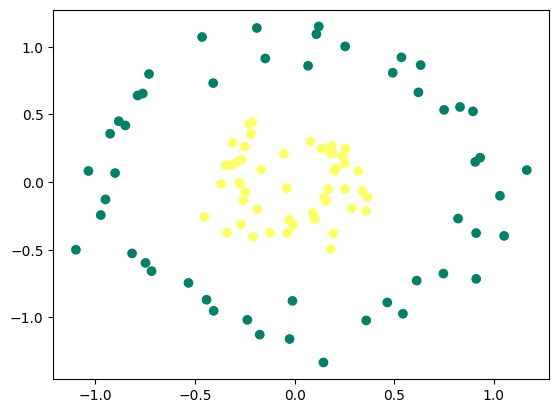

In [2]:
X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=0)
X = X.T
y = y.reshape((1, y.shape[0]))

print("Dimension de X: ", X.shape)
print("Dimension de y: ", y.shape)

plt.scatter(X[0, :], X[1,:], c=y, cmap="summer")
plt.show()

In [3]:
def initializer(n0, n1, n2):
    W1 = np.random.randn(n1, n0)
    b1 = np.random.randn(n1, 1)

    W2 = np.random.randn(n2, n1)
    b2 = np.random.randn(n2, 1)

    paramettres = {
        'W1' : W1,
        'b1' : b1,
        'W2' : W2,
        'b2' : b2
    }    
    return paramettres

In [4]:
def forward_propagation(X, paramettres):
    W1 = paramettres['W1']
    b1 = paramettres['b1']
    W2 = paramettres['W2']
    b2 = paramettres['b2']
    
    Z1 = W1.dot(X) + b1
    A1 = 1/(1 + np.exp(-Z1))

    Z2 = W2.dot(A1) + b2
    A2 = 1/(1 + np.exp(-Z2))

    activations = {
        'A1' : A1,
        'A2' : A2
    }
    
    return activations

In [5]:
# def log_loss(A, y):
#     return 1/len(y)*np.sum(-y*np.log(A) - (1-y)*np.log(1-A))

In [6]:
def back_propagation(X, y, activations, paramettres):
    A1 = activations['A1']
    A2 = activations['A2']
    W2 = paramettres['W2']

    m = y.shape[1]
    
    dZ2 = A2 - y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = np.dot(W2.T, dZ2) * A1 * (1 - A1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)

    gradiants = {
        'dW1' : dW1,
        'db1' : db1,
        'dW2' : dW2,
        'db2' : db2
    }
    
    return gradiants

In [7]:
def update(gradiants, paramettres, learning_rate):
    W1 = paramettres['W1'] - learning_rate*gradiants['dW1']
    b1 = paramettres['b1'] - learning_rate*gradiants['db1']

    W2 = paramettres['W2'] - learning_rate*gradiants['dW2']
    b2 = paramettres['b2'] - learning_rate*gradiants['db2']

    paramettres = {
        'W1' : W1,
        'b1' : b1,
        'W2' : W2,
        'b2' : b2
    }
    
    return paramettres

In [8]:
def predict(X, paramettres):
    activations = forward_propagation(X, paramettres)
    A2 = activations['A2']
    return A2>=0.5

In [9]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
from tqdm import tqdm

In [10]:
def neural_network(X_train, y_train, X_test=None, y_test=None, n1 = 1, learning_rate = 0.1, n_iter = 100):
    
    #Initialization
    n0 = X_train.shape[0]
    n2 = y_train.shape[0]
    paramettres = initializer(n0, n1, n2)

    train_loss = []
    train_acc = []
    test_loss = []
    test_acc = []

    for i in tqdm(range(n_iter)):
        activations = forward_propagation(X_train, paramettres)
        gradiants = back_propagation(X_train, y_train, activations, paramettres)
        paramettres = update(gradiants, paramettres, learning_rate)

        if i%10==0:
            train_loss.append(log_loss(y_train.flatten(), activations['A2'].flatten()))
            y_pred = predict(X_train, paramettres)
            current_accuracy = accuracy_score(y_train.flatten(), y_pred.flatten())
            train_acc.append(current_accuracy)

             # ===== TEST =====
            if X_test is not None and y_test is not None:
                test_activations = forward_propagation(X_test, paramettres)
                y_test_true = y_test.ravel()
                y_test_prob = test_activations["A2"].ravel()

                test_loss.append(log_loss(y_test_true, y_test_prob))

                y_test_pred = (y_test_prob >= 0.5)
                test_acc.append(accuracy_score(y_test_true, y_test_pred))
        
    plt.figure(figsize=(14, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label="Train loss")
    if len(test_loss) > 0:
        plt.plot(test_loss, label="Test loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label="Train acc")
    if len(test_acc) > 0:
        plt.plot(test_acc, label="Test acc")
    plt.legend()
    plt.show()

    return paramettres

100%|█████████████████████████████████████| 1000/1000 [00:00<00:00, 4896.38it/s]


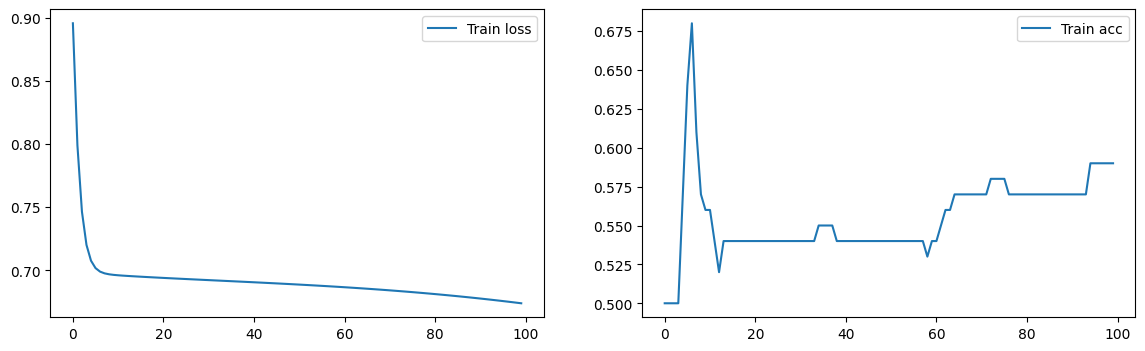

In [11]:
p1 = neural_network(X, y, n1=2, learning_rate=0.1, n_iter=1000)

In [12]:
X_train, y_train, X_test, y_test = load_data()
X_train = X_train.T
X_test = X_test.T
y_train = y_train.T
y_test = y_test.T

# Mise a l'echelle
X_train = X_train.reshape(-1, X_train.shape[-1]) / 255
X_test  = X_test.reshape(-1, X_test.shape[-1]) / 255

m_train = 300
m_test = 80
X_train = X_train[:, :m_train]
y_train = y_train[:, :m_train]
X_test = X_test[:, :m_test]
y_test = y_test[:, :m_test]

100%|██████████████████████████████████████| 1000/1000 [00:06<00:00, 159.15it/s]


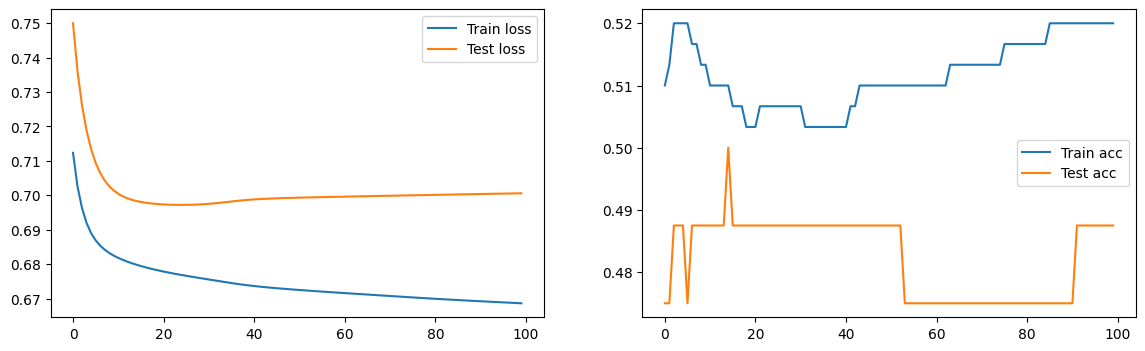

In [13]:
p2 = neural_network(X_train, y_train, X_test=X_test, y_test=y_test, n1=3, learning_rate=0.1, n_iter=1000)